In [1]:
import numpy as np
import numba
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import matplotlib.font_manager
import warnings
from tqdm.notebook import tqdm
from matplotlib import cm
from scipy.special import iv
warnings.filterwarnings("ignore")
plt.rcParams['text.usetex'] = True
plt.rcParams['font.sans-serif'] = "CMU Sans Serif"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['mathtext.fontset'] = 'cm' 
matplotlib.rcParams['axes.unicode_minus'] = True

cmap = cm.magma
c1 = 'crimson'
c2 = cmap(.2)
c3 = 'darkgreen'

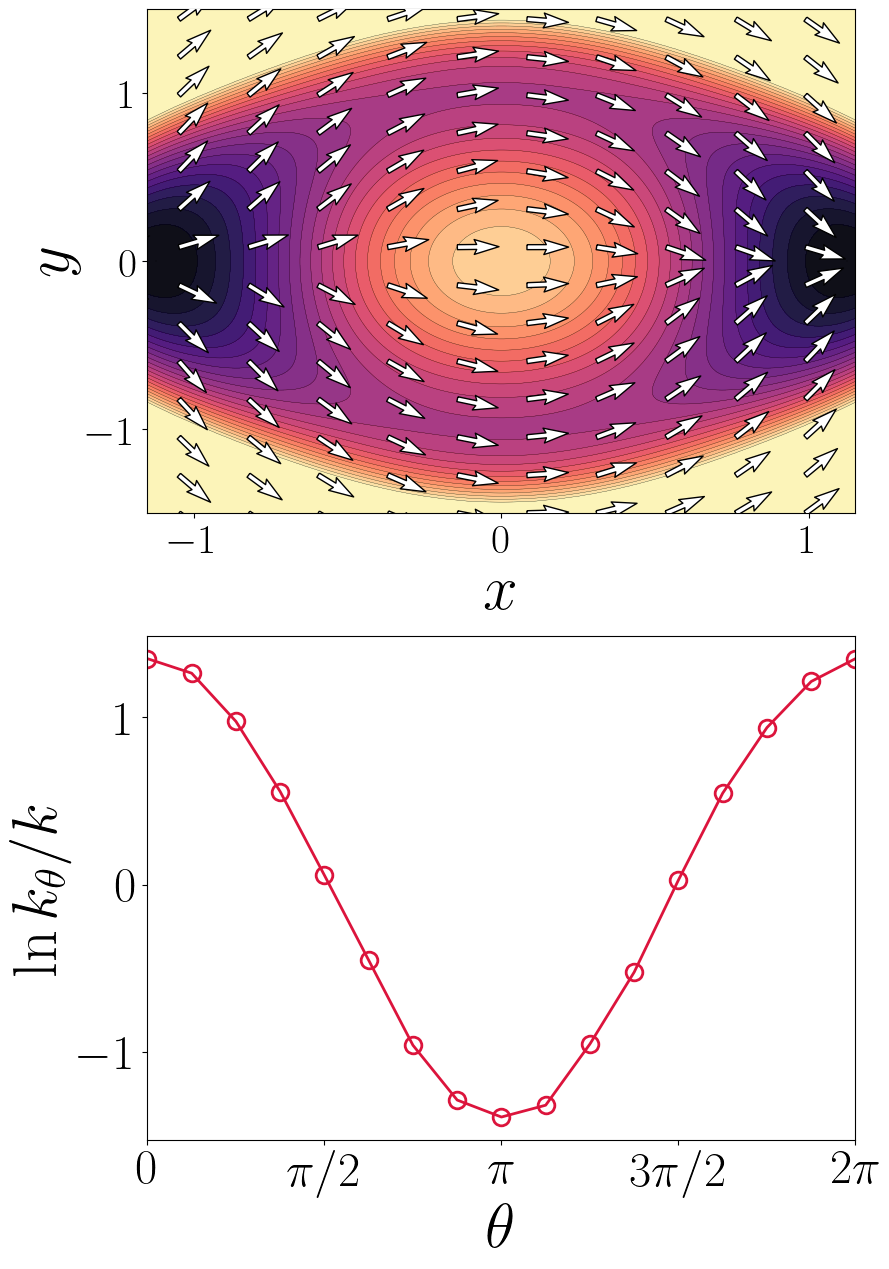

In [2]:
data = np.load("plot_data/fig_01.npz")

q_field     = data["q_field"]
linear_bias = data["linear_biasing"]
align_stats = data["align_stats"]

dat = q_field.reshape(200, 200, 4)
xs  = dat[0, :, 0]
ys  = dat[:, 0, 1]
Ngrids = 200

def calcConservativePotential(r):
    return 2*4/3*(6 + 4*(r[...,0])**4 - 6*r[...,1]**2 + 3*r[...,1]**4 + 10*r[...,0]**2*(r[...,1]**2 - 1))

V = calcConservativePotential(dat[:, :, :2]).reshape(200, 200)
V -= np.min(V)
V[V > 18] = 18
V = V.reshape(Ngrids, Ngrids)

fig, axs = plt.subplots(2, figsize=(9, 16/10*8))

ax = axs[0]
cf = ax.contourf(xs, ys, V, levels=25, cmap=cmap, alpha=0.95)
ax.contour(xs, ys, V, levels=25, colors='k', linewidths=0.2)
dc = 15
ax.quiver(xs[::dc], ys[::dc], dat[::dc, ::dc, 2], dat[::dc, ::dc, 3],
          alpha=1, facecolor='w', edgecolor='k', scale=17, width=0.007, lw=1, zorder=100)
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.5, 1.5)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=30)
ax.set_xlabel(r'$x$', fontsize=45)
ax.set_ylabel(r'$y$', fontsize=45)

ax = axs[1]
ax.errorbar(linear_bias[:, 0], -linear_bias[:, 1] - align_stats[0][1],
            marker='o', mfc='None', mew=2, ms=12, c=c1, lw=2)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
              ["$0$", "$\\pi/2$", "$\\pi$", "$3\\pi/2$", "$2\\pi$"])
ax.tick_params(axis='both', labelsize=35)
ax.set_xlabel(r'$\theta$', fontsize=45)
ax.set_ylabel(r'$\ln k_\theta / k$', fontsize=45)
ax.set_xlim(0, 2*np.pi)

plt.tight_layout()

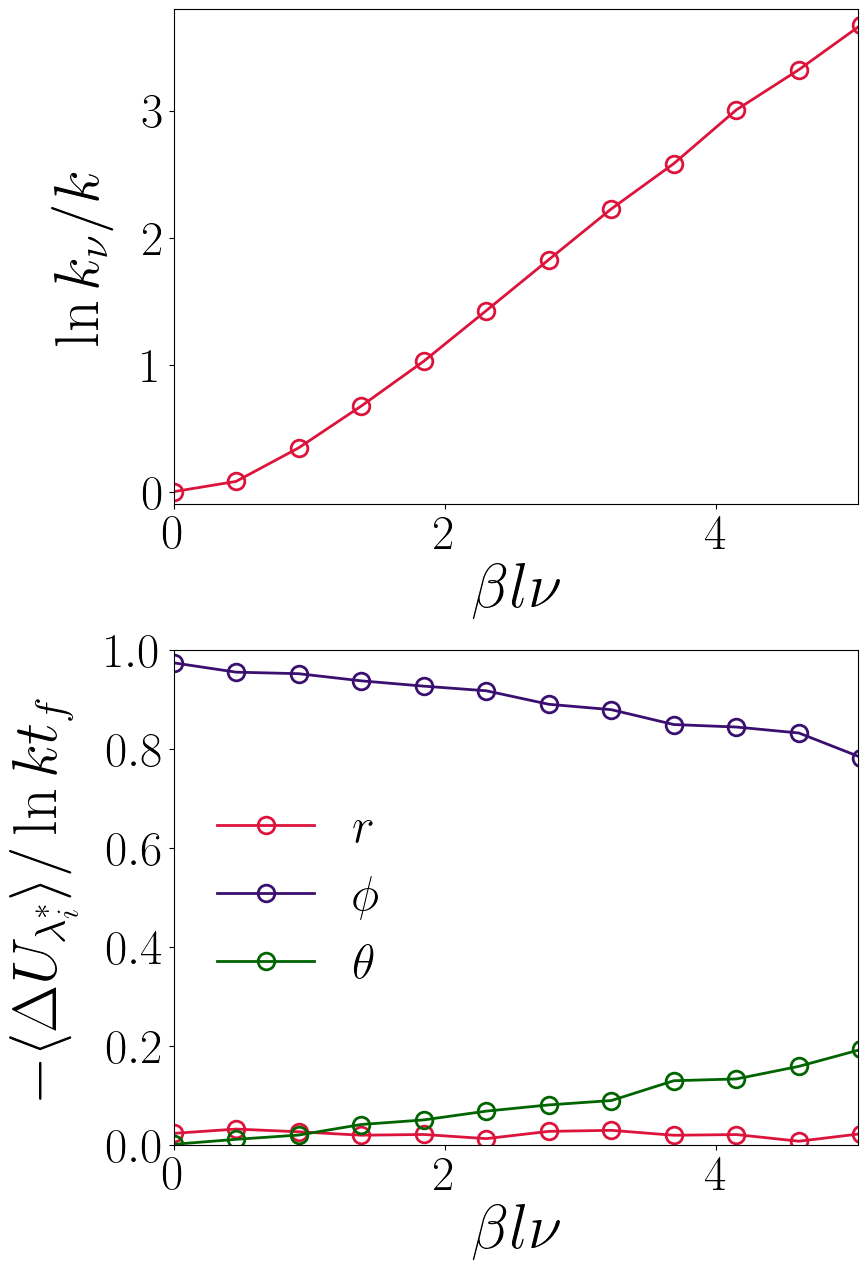

In [4]:
data = np.load("plot_data/fig_02.npz")

align_stats = data["align_stats"]
contrib     = data["contributions"]

fig, axs = plt.subplots(2, figsize=(9, 16/10*8))

ax = axs[0]
ax.errorbar(align_stats[::3, 0][:12],
            align_stats[::3, 1][:12] - align_stats[0, 1],
            marker='o', mfc='None', mew=2, ms=12, c=c1, lw=2)
ax.tick_params(axis='both', labelsize=35)
ax.set_xlabel(r'$\beta l \nu$', fontsize=45)
ax.set_ylabel(r'$\ln k_{\nu} / k$', fontsize=45, labelpad=20)
ax.set_xlim(0, 5.05)
ax.set_ylim(-.1, 3.8)

ax = axs[1]
ax.plot(contrib[:, 0], contrib[:, 1],
        marker='o', mfc='None', mew=2, ms=12, c=c1, lw=2, label=r'$r$')
ax.plot(contrib[:, 0], contrib[:, 2],
        marker='o', mfc='None', mew=2, ms=12, c=c2, lw=2, label=r'$\phi$')
ax.plot(contrib[:, 0], contrib[:, 3],
        marker='o', mfc='None', mew=2, ms=12, c=c3, lw=2, label=r'$\theta$')
ax.tick_params(axis='both', labelsize=35)
ax.set_xlim(0, 5.05)
ax.set_ylim(0, 1)
ax.set_xlabel(r'$\beta l \nu$', fontsize=45)
ax.set_ylabel(r'$-\langle \Delta U_{\lambda^*_i}  \rangle / \ln k t_f$', fontsize=45, labelpad=20)
ax.legend(fontsize=35, frameon=False, loc='center left')

plt.tight_layout()

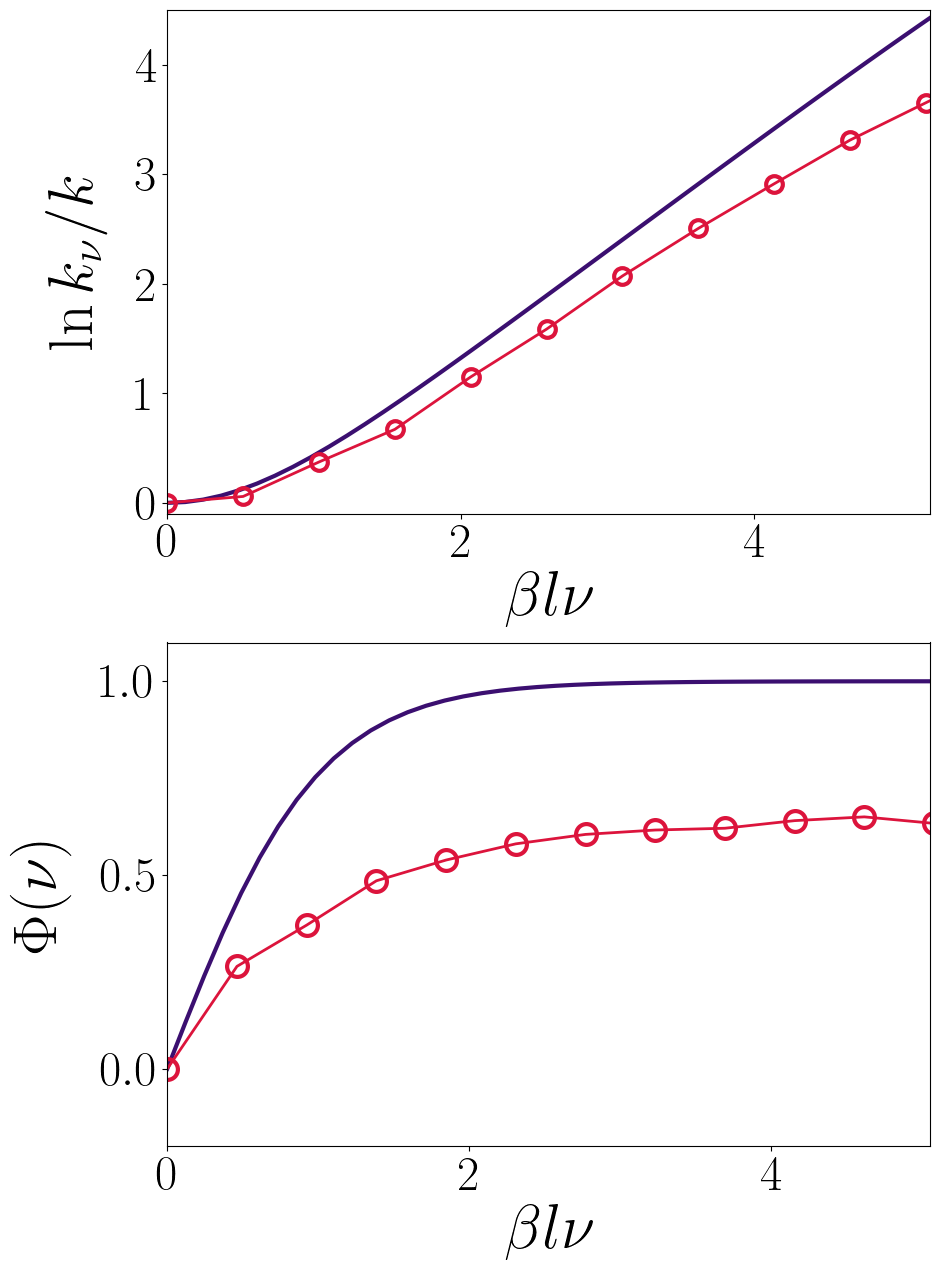

In [6]:
data = np.load("plot_data/fig_03.npz")

lnk2d       = data["lnk2d"]
align_stats = data["align_stats"]

fig, axs = plt.subplots(2, figsize=(9.5, 16/10*8))

ax = axs[0]
ax.plot(
    np.linspace(0, 6),
    np.log((np.exp(-7) + np.cosh(np.linspace(0, 6))) / (1 + np.exp(-7) * np.cosh(np.linspace(0, 6)))),
    color=c2,
    lw=3,
    label=r'$\textrm{MSM}$'
)
ax.plot(
    lnk2d[:, 0],
    lnk2d[:, 1] - lnk2d[0, 1],
    '-o',
    mew=3,
    ms=12,
    c=c1,
    lw=2,
    mfc='None',
    label=r'$\textrm{2D}$'
)
ax.tick_params(axis='both', labelsize=35)
ax.set_xlabel(r'$\beta l \nu$', fontsize=45)
ax.set_ylabel(r'$\ln k_{\nu} / k$', fontsize=45, labelpad=20)
ax.set_xlim(0, 5.2)
ax.set_ylim(-.1, 4.5)

ax = axs[1]
stat2d = align_stats[::3][:12]
ax.plot(
    np.linspace(0, 6),
    np.sinh(np.linspace(0, 6)) / (np.exp(-7) + np.cosh(np.linspace(0, 6))),
    lw=3,
    c=c2,
    label=r'$\textrm{MSM}$'
)
ax.plot(
    stat2d[:, 0],
    stat2d[:, 2],
    '-o',
    mew=3,
    ms=15,
    c=c1,
    lw=2,
    mfc='None',
    label=r'$\textrm{2D}$'
)
ax.tick_params(axis='both', labelsize=35)
ax.set_xlim(0, 5.05)
ax.set_ylim(-.2, 1.1)
ax.set_xlabel(r'$\beta l \nu$', fontsize=45)
ax.set_ylabel(r'$\Phi (\nu)$', fontsize=45, labelpad=20)

plt.tight_layout()

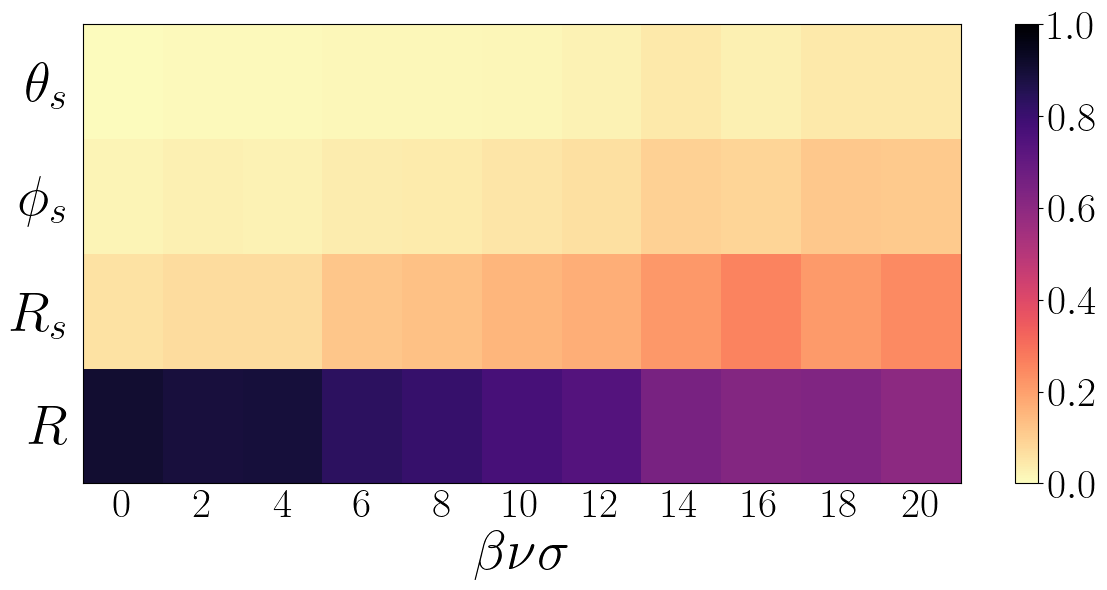

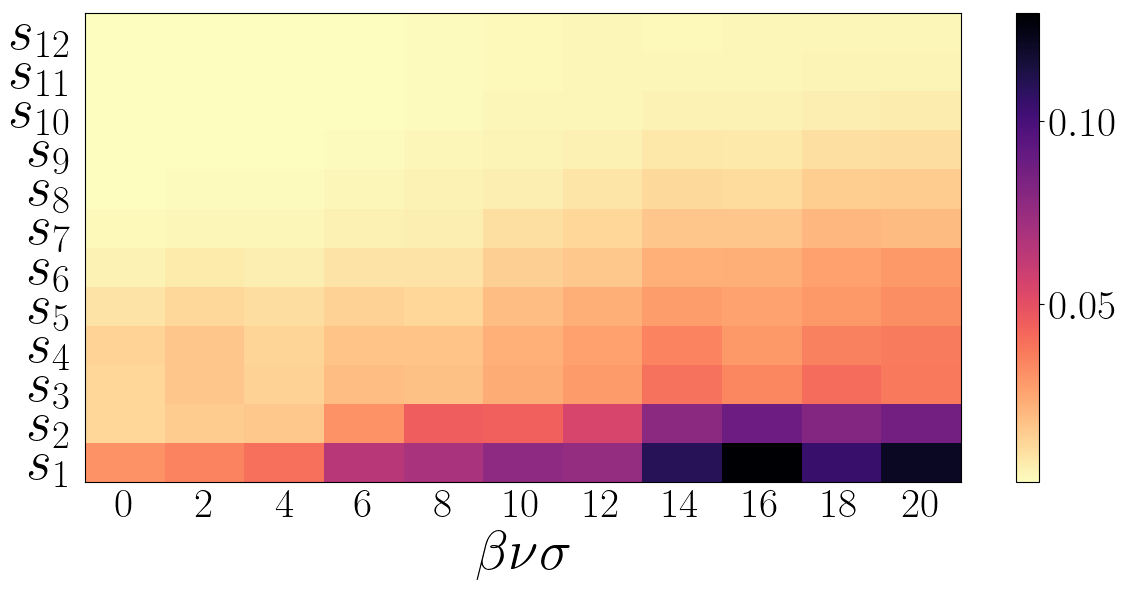

In [8]:
data = np.load("plot_data/fig_05.npz")
Ucont = data["dimer_contributions"].copy()

fig = plt.figure(figsize=(12, 6))
Usol = np.swapaxes(np.array([
    Ucont[:, 1::5],
    Ucont[:, 2::5] + Ucont[:, 3::5],
    Ucont[:, 4::5] + Ucont[:, 4::5],
]).T, 0, 1)
Utot = np.concatenate([Ucont[:, :1], Usol.sum(axis=1)], axis=-1)
plt.pcolormesh(Utot.T, cmap='magma_r', vmax=1, vmin=0)
plt.yticks(np.arange(4) + .5, ['$R$', '$R_s$', '$\\phi_s$', '$\\theta_s$'], size=40)
plt.tick_params(axis='both', size=0.)
plt.tick_params(axis='y', pad=10)
plt.xticks(np.arange(11) + .5, ['${:d}$'.format(i * 2) for i in np.arange(11)], fontsize=30)
plt.xlabel('$\\beta \\nu \\sigma $', fontsize=40)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=30)
plt.tight_layout()

fig = plt.figure(figsize=(12, 6))
Usol = np.swapaxes(np.array([
    Ucont[:, 1::5],
    Ucont[:, 2::5] + Ucont[:, 3::5],
    Ucont[:, 4::5] + Ucont[:, 4::5],
]).T, 0, 1)
plt.pcolormesh(Usol.sum(axis=-1).T, cmap='magma_r')
plt.yticks(size=20)
plt.xticks(np.arange(11) + .5, ['${:d}$'.format(i * 2) for i in np.arange(11)], fontsize=30)
plt.yticks(np.arange(12) + .6, ['$s_{' + '{:.0f}'.format(i) + '}$' for i in np.arange(1, 12.1)], size=40)
plt.xlabel('$\\beta \\nu \\sigma $', fontsize=40)
plt.tick_params(axis='both', size=0.)
plt.tick_params(axis='y', pad=10)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=30)
plt.tight_layout()

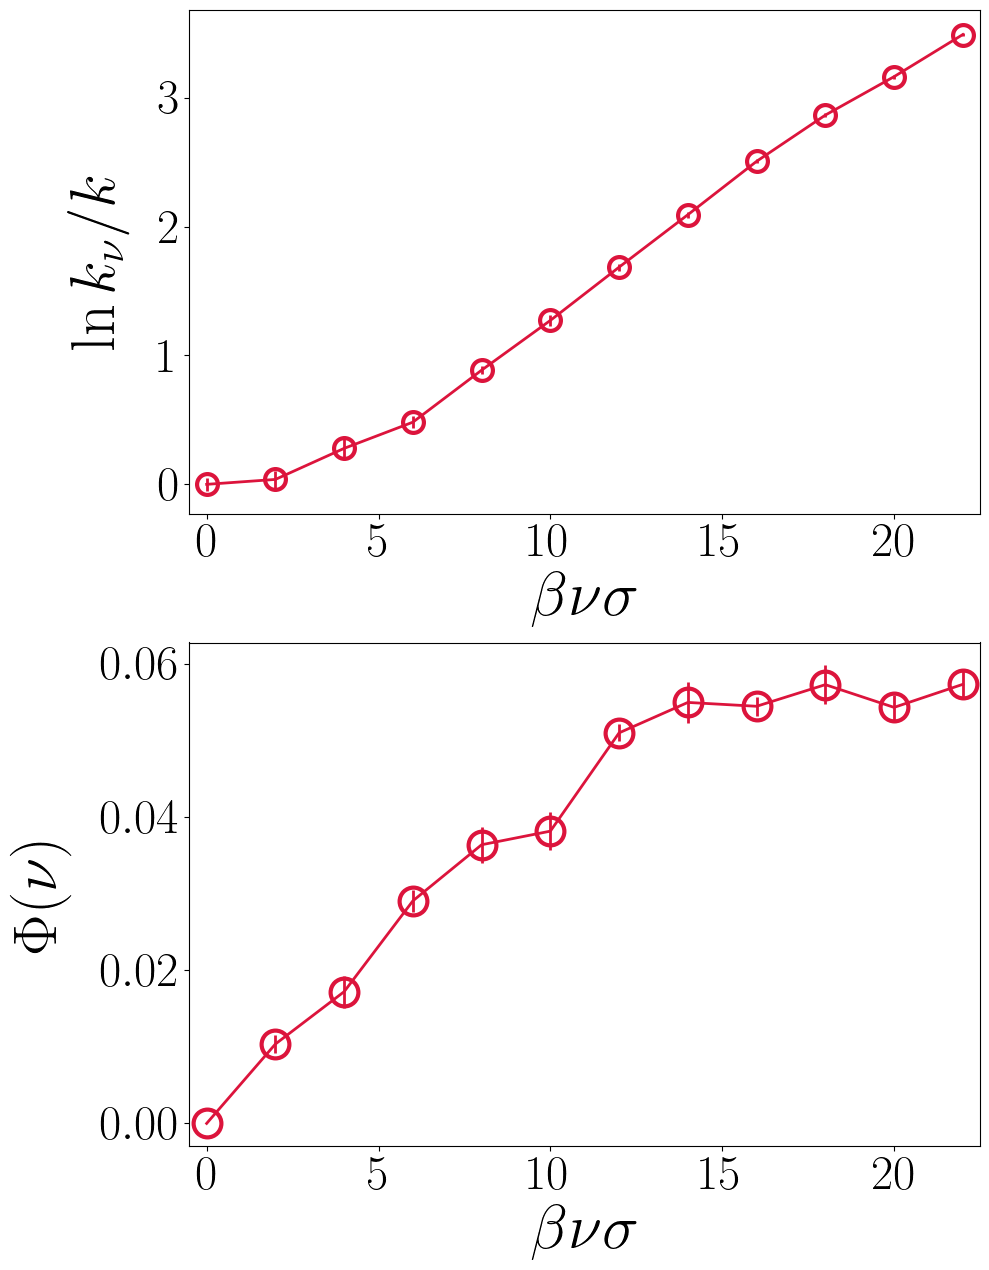

In [12]:
data = np.load("plot_data/fig_06.npz")

lnkdimer    = data["dimer_lnk"]
dimer_stats = data["dimer_stats"]
sample      = data["sample_align"]
tmp_dirs    = data["tmp_dirs"]
rate_table  = data["rate_table"]

fig, axs = plt.subplots(2, figsize=(10, 16/10*8))

ax = axs[0]
ax.errorbar(rate_table[:, 0], rate_table[:, 1], rate_table[:, 2],
            marker='o', mew=3, ms=15, c=c1, lw=2, mfc='None')
ax.tick_params(axis='both', labelsize=35)
ax.set_xlabel(r'$\beta \nu \sigma$', fontsize=45)
ax.set_ylabel(r'$\ln k_{\nu} / k$', fontsize=45, labelpad=20)
ax.set_xlim(-.5, 22.5)

ax = axs[1]
ax.errorbar(dimer_stats[:, 0], dimer_stats[:, 1], dimer_stats[:, 2],
            marker='o', mew=3, ms=20, c=c1, lw=2, mfc='None')
ax.tick_params(axis='both', labelsize=35)
ax.set_xlim(-.5, 22.5)
ax.set_xlabel(r'$\beta \nu \sigma$', fontsize=45)
ax.set_ylabel(r'$\Phi (\nu)$', fontsize=45, labelpad=20)

plt.tight_layout()

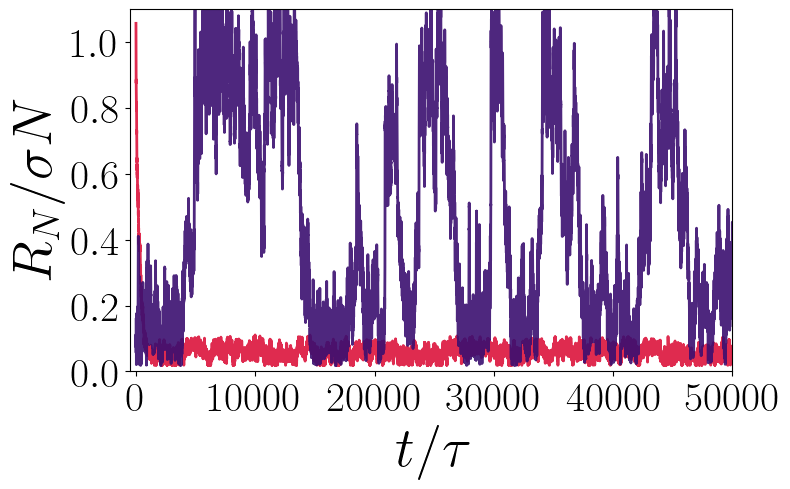

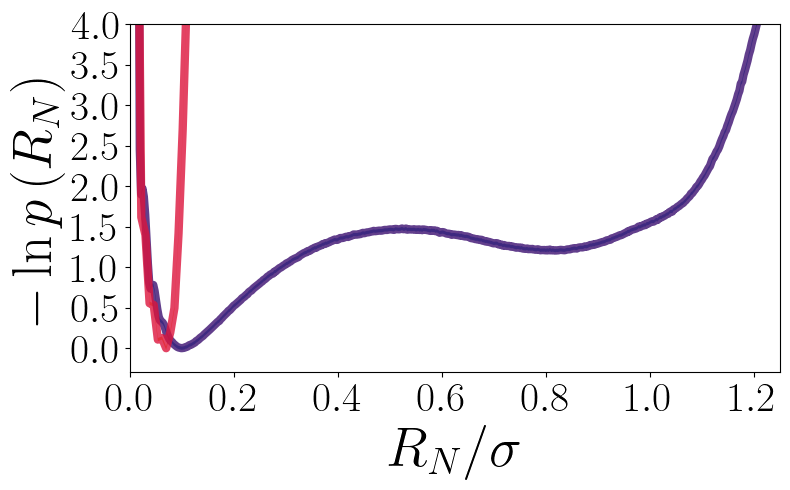

In [13]:
data = np.load("plot_data/fig_09.npz")

traj_active = data["traj_active"]
traj_eq     = data["traj_eq"]
lnp_active  = data["lnp_active"]
lnp_eq      = data["lnp_eq"]

fig = plt.figure(figsize=(8, 5))
plt.plot(traj_eq[:, 0], traj_eq[:, 1], lw=2, color=c1, alpha=0.9)
plt.plot(traj_active[:, 0], traj_active[:, 1], lw=2, color=c2, alpha=0.9)
plt.ylim(0., 1.1)
plt.xlim(-500, 50000)
plt.xticks(size=30)
plt.yticks(size=30)
plt.xlabel(r'$t/\tau$', fontsize=40)
plt.ylabel(r'$R_N/\sigma N$', fontsize=40)
plt.tight_layout()

fig = plt.figure(figsize=(8, 5))
plt.plot(lnp_active[:, 0], lnp_active[:, 1], lw=6, color=c2, alpha=0.8)
plt.fill_between(lnp_active[:, 0],
                 lnp_active[:, 1] - 0.02,
                 lnp_active[:, 1] + 0.02,
                 alpha=0.8)
plt.plot(lnp_eq[:, 0], lnp_eq[:, 1], lw=6, color=c1, alpha=0.8)
plt.fill_between(lnp_eq[:, 0],
                 lnp_eq[:, 1] - 0.02,
                 lnp_eq[:, 1] + 0.02,
                 alpha=0.8)
plt.xlim(0, 1.25)
plt.ylim(-.3, 4.)
plt.xticks(size=30)
plt.yticks(size=30)
plt.xlabel(r'$R_N/\sigma$', fontsize=40)
plt.ylabel(r'$-\ln p\left(R_N\right)$', fontsize=40)
plt.tight_layout()

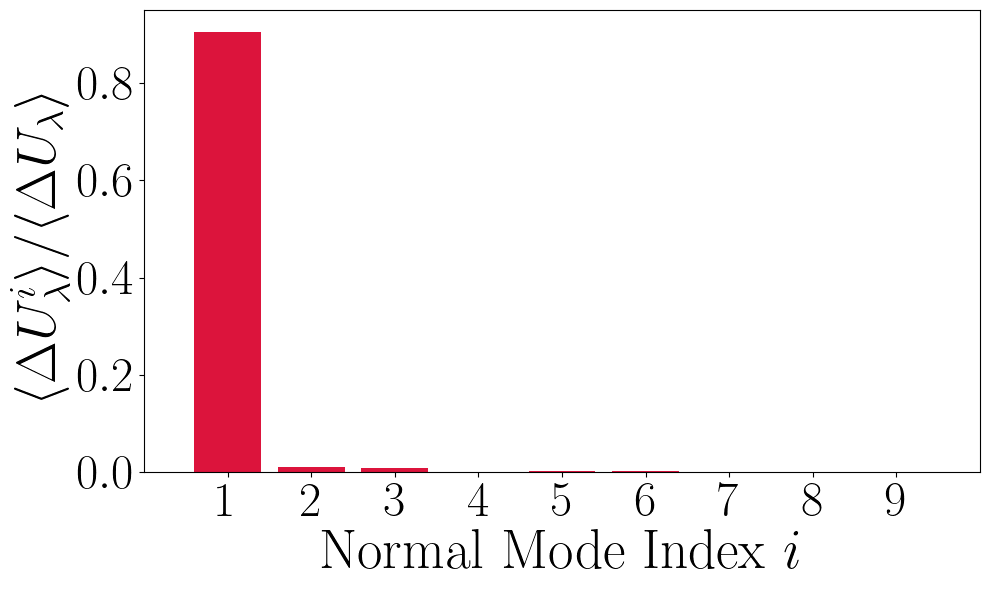

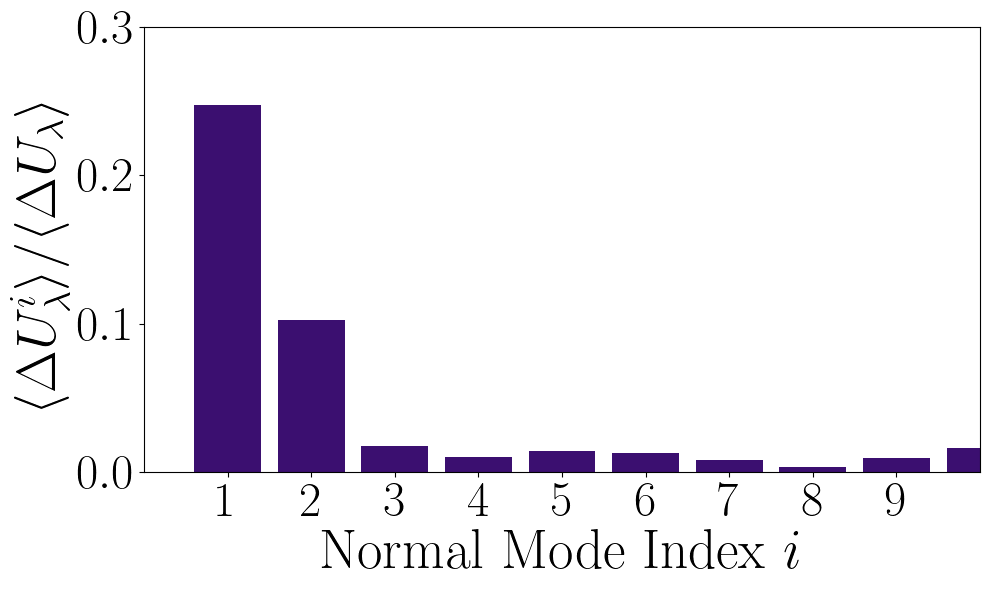

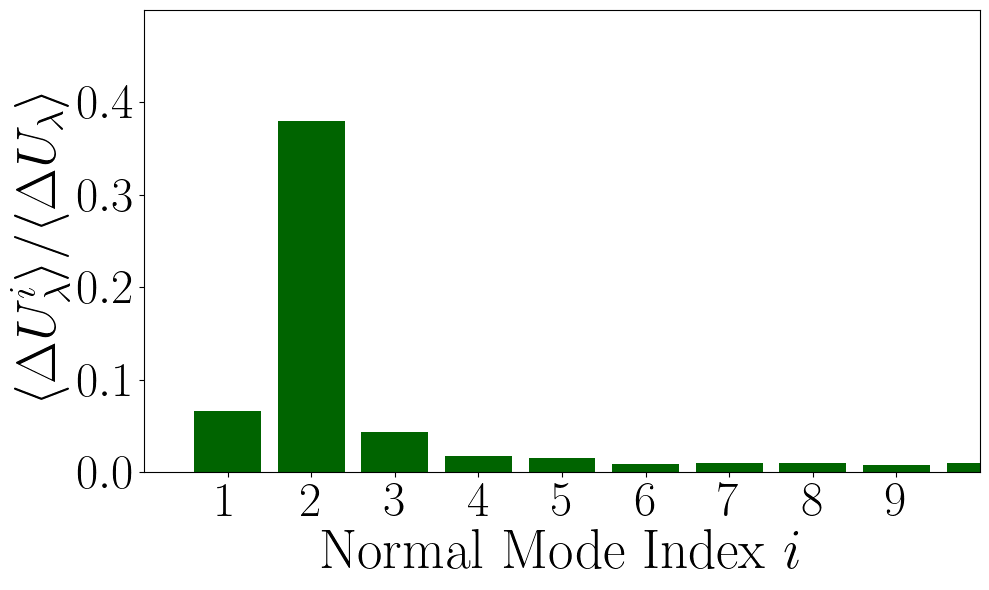

In [14]:
data = np.load("plot_data/fig_10.npz")

eq_dat   = data["eq_dat"]
unfold   = data["unfolding"]
fold     = data["folding"]

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.bar(np.arange(1, eq_dat.shape[0] + 1), eq_dat, color=c1)
ax.set_xlim(0, 10)
ax.set_ylim(0, .95)
ax.set_yticks(np.arange(0, 9, 2) / 10)
ax.set_xticks(np.arange(1, 10))
ax.set_xlabel(r'$\textrm{Normal Mode Index }i$', fontsize=40)
ax.set_ylabel(r'$\langle \Delta U_{\lambda}^i \rangle / \langle \Delta U_{\lambda} \rangle$', fontsize=40)
ax.tick_params(labelsize=35)
plt.tight_layout()

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.bar(np.arange(1, unfold.shape[0] + 1), unfold[:unfold.shape[0]], color=c2)
ax.set_xlim(0, 10)
ax.set_ylim(0, .3)
ax.set_yticks(np.arange(0, 4, 1) / 10)
ax.set_xticks(np.arange(1, 10))
ax.set_xlabel(r'$\textrm{Normal Mode Index }i$', fontsize=40)
ax.set_ylabel(r'$\langle \Delta U_{\lambda}^i \rangle / \langle \Delta U_{\lambda} \rangle$', fontsize=40)
ax.tick_params(labelsize=35)
plt.tight_layout()

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.bar(np.arange(1, fold.shape[0] + 1), fold, color=c3)
ax.set_xlim(0, 10)
ax.set_ylim(0, .5)
ax.set_yticks(np.arange(0, 5, 1) / 10)
ax.set_xticks(np.arange(1, 10))
ax.set_xlabel(r'$\textrm{Normal Mode Index }i$', fontsize=40)
ax.set_ylabel(r'$\langle \Delta U_{\lambda}^i \rangle / \langle \Delta U_{\lambda} \rangle$', fontsize=40)
ax.tick_params(labelsize=35)
plt.tight_layout()

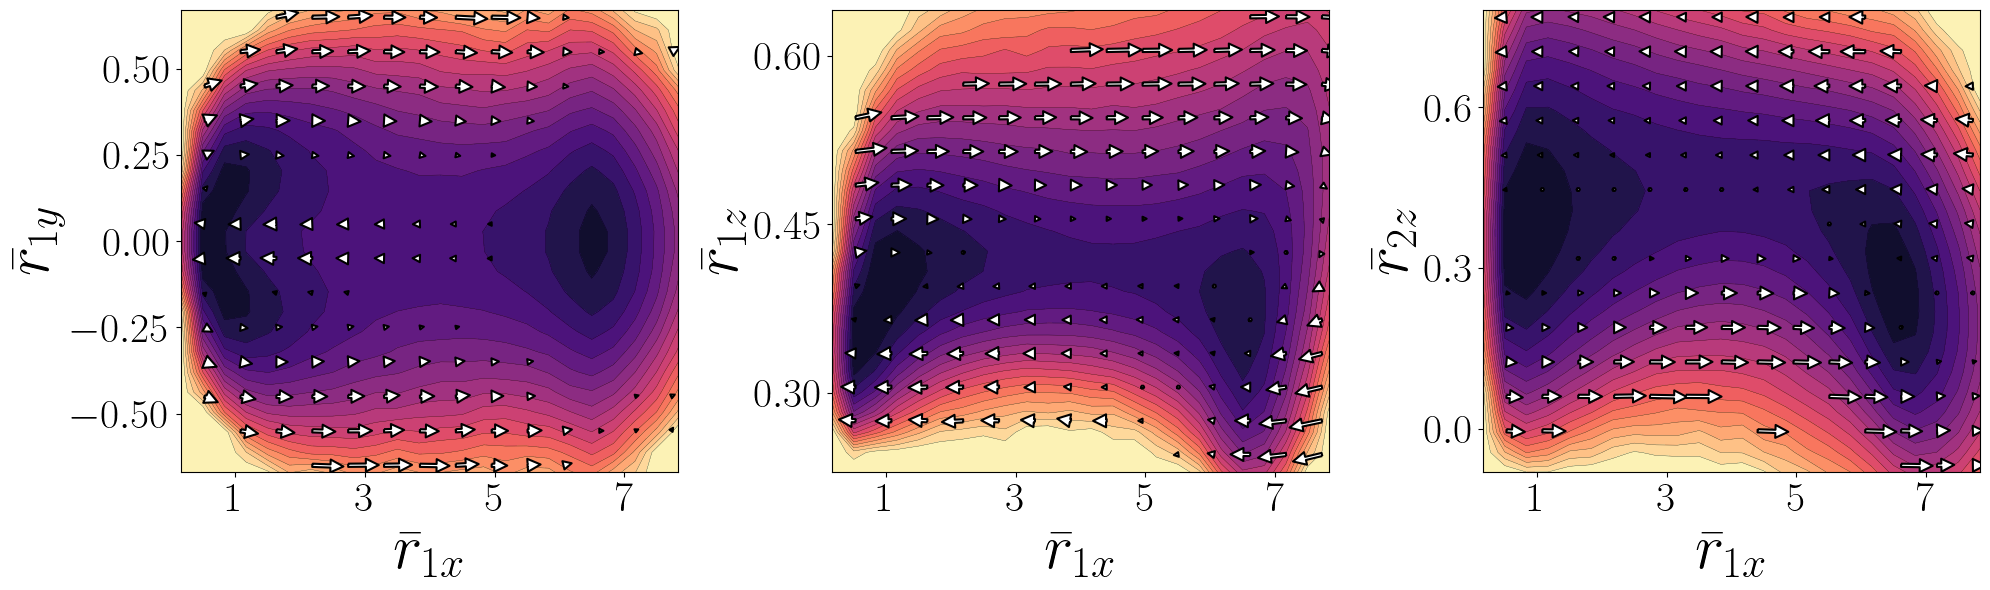

In [15]:
data = np.load("plot_data/fig_11.npz")

p1 = data["p_r1x_r1y"]
p2 = data["p_r1x_r1z"]
p3 = data["p_r1x_r2z"]

f1 = data["f_r1x_r1y"]
f2 = data["f_r1x_r1z"]
f3 = data["f_r1x_r2z"]

fig, axs = plt.subplots(1, 3, figsize=(20, 6))
axs = axs.T
width = 0.0065
vmax = 9
eps = .2
scales = [30, 65, 65]

p_list = [p1, p2, p3]
f_list = [f1, f2, f3]
xlabels = [r'$\bar r_{1x}$', r'$\bar r_{1x}$', r'$\bar r_{1x}$']
ylabels = [r'$\bar r_{1y}$', r'$\bar r_{1z}$', r'$\bar r_{2z}$']

for i in range(3):
    ax = axs[i]
    p = p_list[i]
    x = p[0, :, 0]
    y = p[:, 0, 1]
    z = p[..., -1].reshape(-1)
    z[z > vmax] = vmax
    z = z.reshape(p.shape[:2])

    ax.contourf(x, y, z, cmap='magma', levels=np.linspace(-0.5, vmax, 20), alpha=0.99)
    ax.contour(x, y, z, colors='k', linewidths=0.2,
               levels=np.linspace(-0.5, vmax, 20), alpha=1.)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(y[0], y[-1])

    f = f_list[i].reshape(-1, 4)
    f[np.linalg.norm(f[..., -2:], axis=-1) < eps, 2:] = np.nan
    f = f.reshape(14, 14, 4)
    xf = f[0, :, 0]
    yf = f[:, 0, 1]
    ax.quiver(xf, yf, f[..., 2].T, f[..., 3].T,
              color='white',
              scale=scales[i],
              width=width,
              zorder=100,
              edgecolor='k',
              linewidth=1.5,
              headwidth=4,
              headaxislength=4,
              headlength=4)

    ax.set_xlabel(xlabels[i], fontsize=45)
    ax.set_ylabel(ylabels[i], fontsize=45)
    ax.tick_params(axis='both', labelsize=30)

axs[0].set_xticks([1, 3, 5, 7])
axs[0].set_yticks([-.5, -.25, 0, .25, .5])
axs[1].set_xticks([1, 3, 5, 7])
axs[1].set_yticks([.3, .45, .6])
axs[2].set_xticks([1, 3, 5, 7])
axs[2].set_yticks([0, .3, .6])

plt.tight_layout()

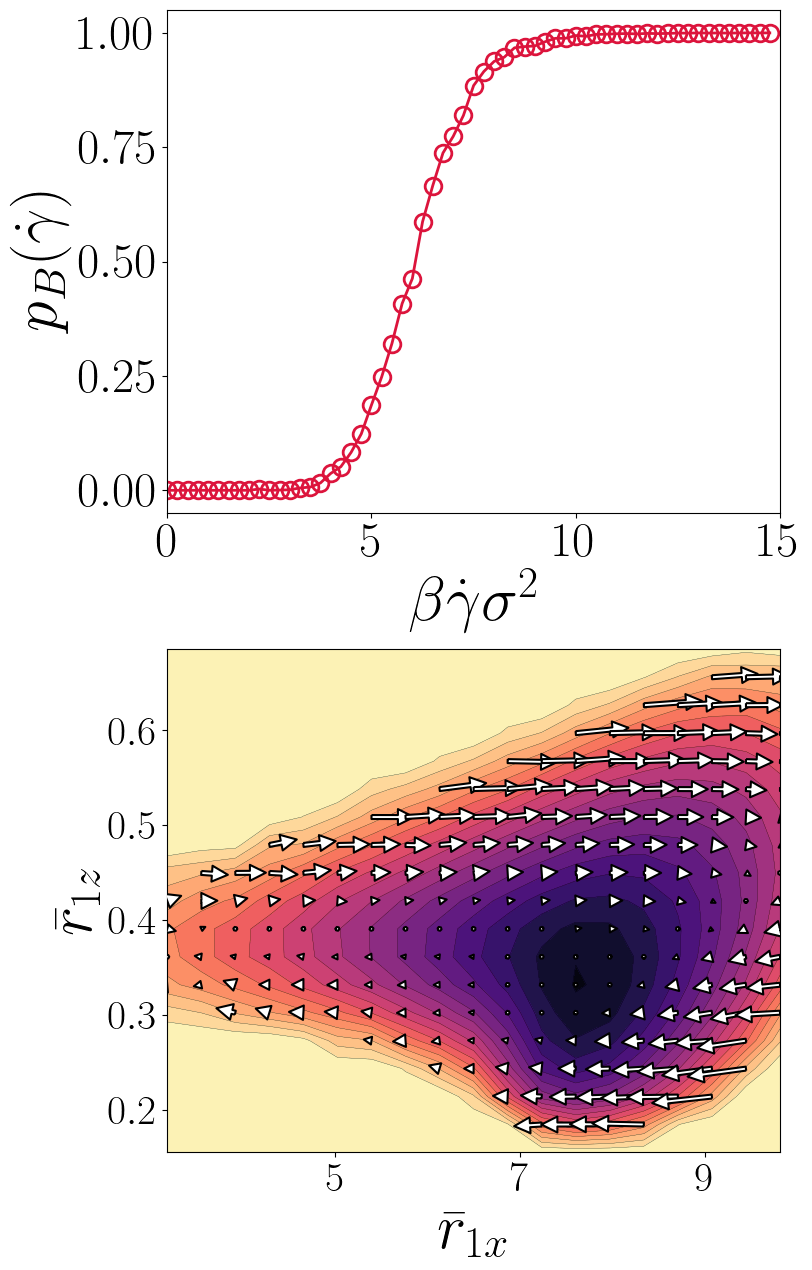

In [16]:
data = np.load("plot_data/fig_12.npz")

shear_sweep = data["shear_sweep"]
lnp_8  = data["lnp_8"]
lnp_30 = data["lnp_30"]
lnf_8  = data["lnf_8"]
lnf_30 = data["lnf_30"]

fig, axs = plt.subplots(2, figsize=(8, 16/10*8))

ax = axs[0]
ax.plot(shear_sweep[:, 0] * 0.5,
        shear_sweep[:, 1],
        '-o', mfc='None', mew=2, ms=12, c=c1, lw=2)
ax.set_ylabel(r'$p_B(\dot \gamma)$', fontsize=45)
ax.set_xlabel(r'$\beta \dot \gamma \sigma^2$', fontsize=45)
ax.tick_params(axis='both', labelsize=35)
ax.set_xlim(0, 15)

ax = axs[1]
p = lnp_30
f = lnf_30
vmax = 10
eps = .2
width = 0.0065
scale = 50000

x = p[0, :, 0]
y = p[:, 0, 1]
z = p[..., -1].reshape(-1)
z[z > vmax] = vmax
z = z.reshape(p.shape[:2])

ax.contourf(x, y, z, cmap='magma', levels=np.linspace(-0.5, vmax, 20), alpha=0.99)
ax.contour(x, y, z, colors='k', linewidths=0.2,
           levels=np.linspace(-0.5, vmax, 20), alpha=1.)

f = f.reshape(-1, 4)
f[np.linalg.norm(f[..., -2:], axis=-1) < eps, 2:] = np.nan
f = f.reshape(19, 19, 4)
xf = f[0, :, 0]
yf = f[:, 0, 1]

ax.quiver(xf, yf, f[..., 2].T, f[..., 3].T,
          color='white',
          scale=scale,
          width=width,
          zorder=100,
          edgecolor='k',
          linewidth=1.5,
          headwidth=4,
          headaxislength=4,
          headlength=4)
ax.set_xticks([1, 3, 5, 7, 9])
ax.tick_params(axis='both', labelsize=30)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(y[0], y[-1])
ax.set_xlabel(r'$\bar r_{1x}$', fontsize=45)
ax.set_ylabel(r'$\bar r_{1z}$', fontsize=45)

plt.tight_layout()

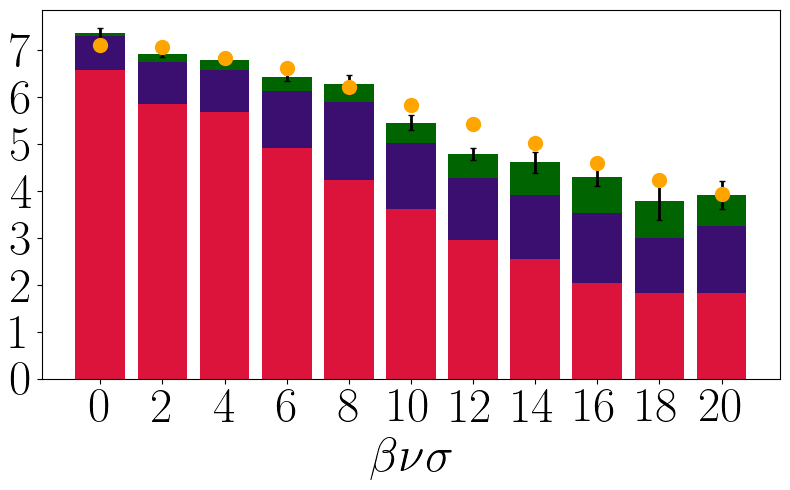

In [17]:
data = np.load("plot_data/fig_15.npz")

dat       = data["train_stats"]
rate      = data["rate_table"]

fig = plt.figure(figsize=(8, 5))
x = dat[:, 0] / 2.0
plt.bar(x, -dat[:, 2] - np.log(dat[:, 4]), color=c3)
plt.bar(x, -dat[:, 2],               color=c2)
plt.bar(x,  dat[:, 1],               color=c1)
plt.errorbar(x,
             -dat[:, 2] - np.log(dat[:, 4]),
             dat[:, 3],
             color='k',
             ls='None',
             lw=2,
             capsize=2)
plt.plot(x, -rate[:-1, 1] + 7.1, 'o', ms=10, c='orange')
plt.xticks(np.arange(11)*1, [f'${i*2:d}$' for i in range(11)], size=35)
plt.yticks(size=35)
plt.xlabel(r'$\beta \nu \sigma$', size=35)
plt.tight_layout()

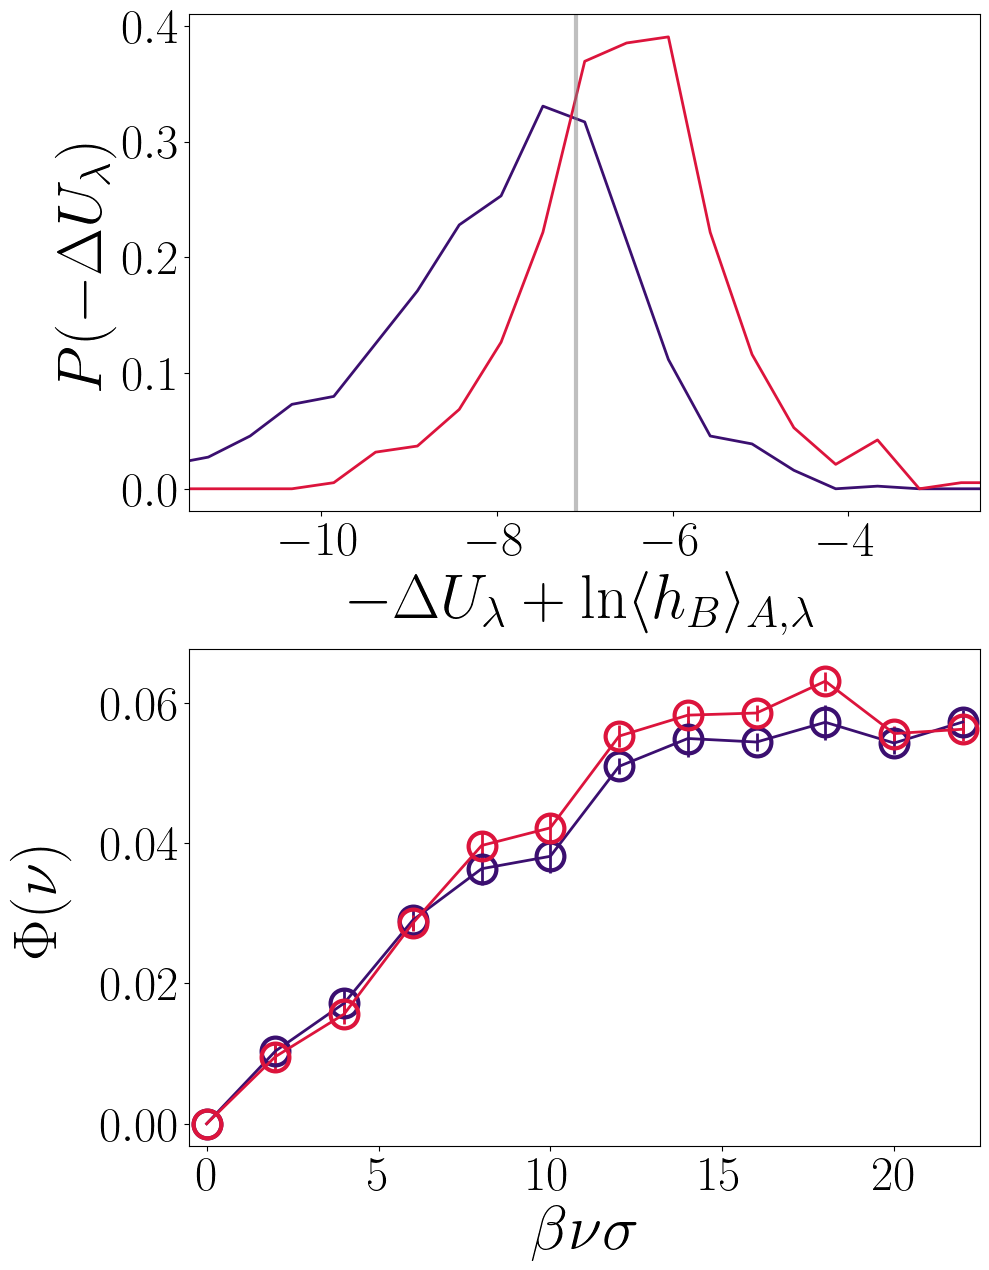

In [18]:
data = np.load("plot_data/fig_16.npz")

final_stats    = data["final_stats"]
dimer_stats    = data["dimer_stats"]
dimer_stats_ss = data["dimer_stats_ss"]

fig, axs = plt.subplots(2, figsize=(10, 16/10*8))

ax = axs[0]
ax.plot(final_stats[:, 0], final_stats[:, 1], lw=2, c=c2)
ax.plot(final_stats[:, 0], final_stats[:, 2], lw=2, c=c1)
ax.axvline(-7.1, lw=3, c='gray', alpha=0.5)
ax.set_xlabel(r'$-\Delta U_{\lambda} + \ln \langle h_{B} \rangle_{A,\lambda}$', fontsize=45)
ax.set_ylabel(r'$P(-\Delta U_{\lambda})$', fontsize=45)
ax.set_xlim(-11.5, -2.5)
ax.tick_params(axis='both', labelsize=35)
plt.tight_layout()

ax = axs[1]
ax.errorbar(dimer_stats[:, 0], dimer_stats[:, 1], dimer_stats[:, 2],
            marker='o', mew=3, ms=20, c=c2, lw=2, mfc='None')
ax.errorbar(dimer_stats_ss[:, 0], dimer_stats_ss[:, 1], dimer_stats_ss[:, 2],
            marker='o', mew=3, ms=20, c=c1, lw=2, mfc='None')
ax.tick_params(axis='both', labelsize=35)
ax.set_xlim(-.5, 22.5)
ax.set_xlabel(r'$\beta \nu \sigma$', fontsize=45)
ax.set_ylabel(r'$\Phi (\nu)$', fontsize=45, labelpad=20)
plt.tight_layout()

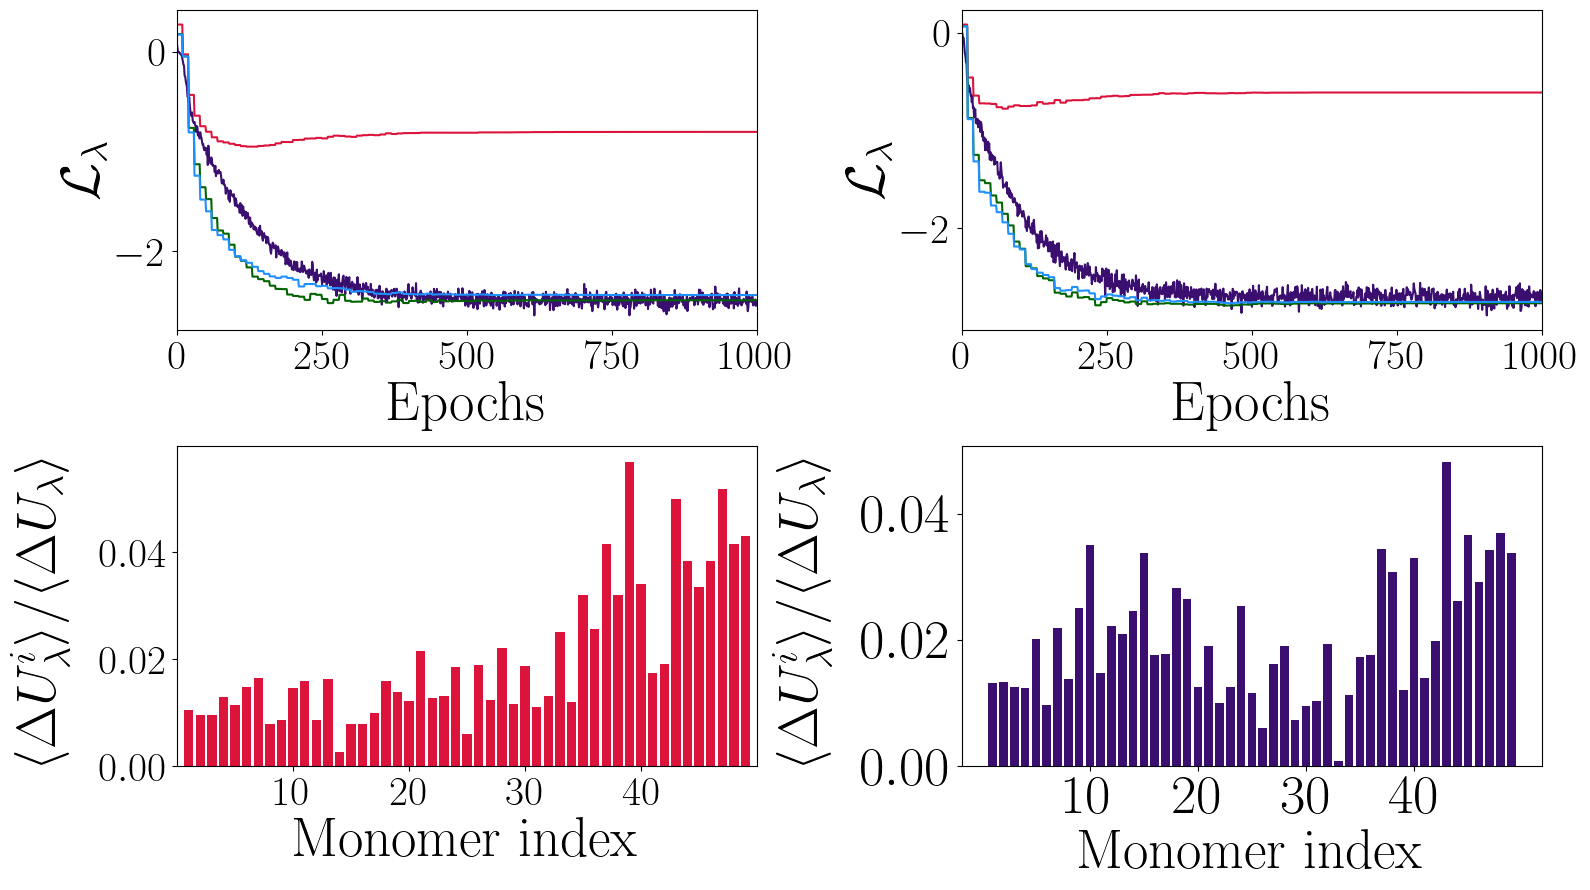

In [19]:
data = np.load("plot_data/fig_17.npz")

unf_loss  = data["unfolding_loss"]
unf_cont  = data["unfolding_contrib"]
fold_loss = data["folding_loss"]
fold_cont = data["folding_contrib"]

fig, axs = plt.subplots(2, 2, figsize=(16, 9))

ax = axs[0][0]
ax.plot(unf_loss[:, 0] * 10, c=c2)
ax.plot(unf_loss[:, 1],      c=c1)
ax.plot(unf_loss[:, 2],      c=c3)
ax.plot(unf_loss[:, 3],      c='dodgerblue')
ax.set_ylabel(r'$\mathcal{L}_{\lambda}$', fontsize=40)
ax.set_xlabel(r'\textrm{Epochs}', fontsize=40)
ax.tick_params(labelsize=30)
ax.set_xlim(0, 1000)

ax = axs[1][0]
cont_unf = np.sum(unf_cont, axis=-1) / np.sum(unf_cont[:, :])
ax.bar(np.arange(49) + 1, cont_unf, color=c1)
ax.set_xlim(0, 50)
ax.set_ylabel(r'$\langle \Delta U_{\lambda}^i \rangle / \langle \Delta U_{\lambda} \rangle$', fontsize=40, labelpad=20)
ax.set_yticks([0, 0.02, 0.04])
ax.tick_params(labelsize=30)
ax.set_xticks([10, 20, 30, 40])
ax.set_xlabel(r'\textrm{Monomer index}', fontsize=40)

ax = axs[0][1]
ax.plot(fold_loss[:, 0] * 10, c=c2)
ax.plot(fold_loss[:, 1],      c=c1)
ax.plot(fold_loss[:, 2],      c=c3)
ax.plot(fold_loss[:, 3],      c='dodgerblue')
ax.set_ylabel(r'$\mathcal{L}_{\lambda}$', fontsize=40)
ax.set_xlabel(r'\textrm{Epochs}', fontsize=40)
ax.tick_params(labelsize=30)
ax.set_xlim(0, 1000)

ax = axs[1][1]
cont_fold = np.sum(fold_cont[:, :], axis=-1) / np.sum(fold_cont[:, :])
ax.bar(np.arange(49) + 1, cont_fold, color=c2)
ax.set_ylabel(r'$\langle \Delta U_{\lambda}^i \rangle / \langle \Delta U_{\lambda} \rangle$', fontsize=40, labelpad=20)
ax.set_yticks([0, 0.02, 0.04])
ax.set_xticks([10, 20, 30, 40])
ax.set_xlabel(r'\textrm{Monomer index}', fontsize=40)
ax.tick_params(labelsize=40)

plt.tight_layout()

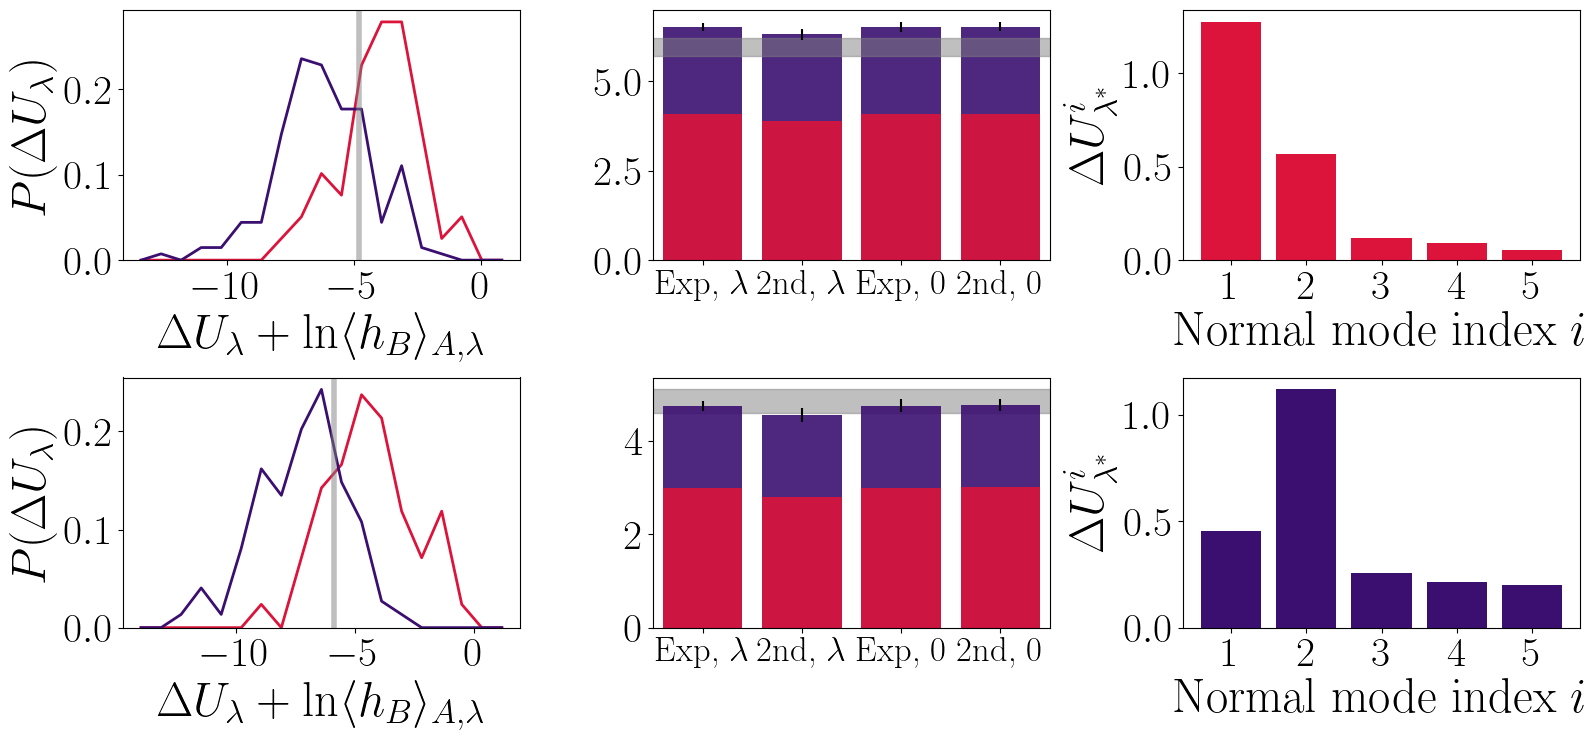

In [21]:
data = np.load("plot_data/fig_18.npz")

unfold_act   = data["unfolding_action"]
fold_act     = data["folding_action"]
unfold_undrv = data["unfolding_undriven_contrib"]
fold_undrv   = data["folding_undriven_contrib"]
unf_driven_stats    = data["unfolding_driven_stats"]
unf_undriven_stats  = data["unfolding_undriven_stats"]
fold_driven_stats   = data["folding_driven_stats"]
fold_undriven_stats = data["folding_undriven_stats"]

unfold_act = unfold_act.copy()
fold_act   = fold_act.copy()
unfold_act[:, 0] += np.log(0.17)
fold_act[:, 0]   += np.log(0.09)

rng = np.random.default_rng(0)

def make_ests_for_unfolding(driven, undriven):
    tmp = driven
    mask = tmp[:, 1] > 45
    tmp2 = -tmp[mask, 2]
    nblocks = int(tmp2.shape[0] // 5)
    a1 = rng.choice(tmp2, (nblocks, 5), replace=False)
    driven_exp = np.log(np.mean(np.exp(a1), axis=0))
    driven_u2  = np.mean(a1, axis=0) + np.var(a1, axis=0) / 2

    ests = []
    ests.append([np.mean(driven_exp), np.std(driven_exp)/2])
    ests.append([np.mean(driven_u2),  np.std(driven_u2)/2])

    tmp2 = undriven
    nblocks = int(tmp2.shape[0] // 5)
    a1 = rng.choice(tmp2, (nblocks, 5), replace=False)
    undr_exp = -np.log(np.mean(np.exp(-a1), axis=0))
    undr_u2  = np.mean(a1, axis=0) - np.var(a1, axis=0) / 2

    ests.append([np.mean(undr_exp), np.std(undr_exp)/2])
    ests.append([np.mean(undr_u2),  np.std(undr_u2)/2])

    ests = np.array(ests)
    react = np.log(np.mean(tmp[:, 1] > 45))
    ests[:, 0] += react
    return ests, react

def make_ests_for_folding(driven, undriven):
    tmp = driven
    mask = tmp[:, 1] < 10
    tmp2 = -tmp[mask, 2]
    nblocks = int(tmp2.shape[0] // 5)
    a1 = rng.choice(tmp2, (nblocks, 5), replace=False)
    driven_exp = np.log(np.mean(np.exp(a1), axis=0))
    driven_u2  = np.mean(a1, axis=0) + np.var(a1, axis=0) / 2

    ests = []
    ests.append([np.mean(driven_exp), np.std(driven_exp)/2])
    ests.append([np.mean(driven_u2),  np.std(driven_u2)/2])

    tmp2 = undriven
    nblocks = int(tmp2.shape[0] // 5)
    a1 = rng.choice(tmp2, (nblocks, 5), replace=False)
    undr_exp = -np.log(np.mean(np.exp(-a1), axis=0))
    undr_u2  = np.mean(a1, axis=0) - np.var(a1, axis=0) / 2

    ests.append([np.mean(undr_exp), np.std(undr_exp)/2])
    ests.append([np.mean(undr_u2),  np.std(undr_u2)/2])

    ests = np.array(ests)
    react = np.log(np.mean(tmp[:, 1] < 10))
    ests[:, 0] += react
    return ests, react

ests_uf, react_uf = make_ests_for_unfolding(unf_driven_stats, unf_undriven_stats)
ests_f,  react_f  = make_ests_for_folding(fold_driven_stats, fold_undriven_stats)

ests_f = np.array(ests_uf)
ests_f[:, 0] += react_uf

fig, axs = plt.subplots(2, 3, figsize=(16, 7.5))

ax = axs[0][0]
ax.plot(unfold_act[:, 0], unfold_act[:, 1], c=c1, lw=2)
ax.plot(unfold_act[:, 0], unfold_act[:, 2], c=c2, lw=2)
ax.tick_params(labelsize=30)
ax.axvline(-4.8, lw=4, alpha=0.5, c='gray')
ax.set_ylabel(r'$P(\Delta U_{\lambda})$', fontsize=35)
ax.set_xlabel(r'$ \Delta U_{\lambda} + \ln \langle h_B\rangle_{A,\lambda} $', fontsize=35)
ax.set_xticks([-10, -5, 0])
ax.set_ylim(0)

ax = axs[1][0]
ax.plot(fold_act[:, 0], fold_act[:, 1], c=c1, lw=2)
ax.plot(fold_act[:, 0], fold_act[:, 2], c=c2, lw=2)
ax.tick_params(labelsize=30)
ax.axvline(-5.9, lw=4, alpha=0.5, c='gray')
ax.set_ylabel(r'$P(\Delta U_{\lambda})$', fontsize=35)
ax.set_xlabel(r'$ \Delta U_{\lambda} + \ln \langle h_B\rangle_{A,\lambda} $', fontsize=35)
ax.set_xticks([-10, -5, 0])
ax.set_ylim(0)

ax = axs[0][1]
ax.bar(np.arange(4), -ests_f[:, 0], color=c2, alpha=0.9)
ax.bar(np.arange(4), -ests_f[:, 0] + react_f, color=c1, alpha=0.9)
ax.errorbar(np.arange(4), -ests_f[:, 0], ests_f[:, 1], ls='None', c='k')
ax.set_xticks([0, 1, 2, 3],
              [r'$\textrm{Exp, }\lambda$', r'$\textrm{2nd, }\lambda$', r'$\textrm{Exp, }0$', r'$\textrm{2nd, }0$'])
ax.fill_between([-1, 5], [5.7, 5.7], [6.2, 6.2], alpha=0.5, color='gray')
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=30)
ax.set_xlim(-0.5, 3.5)

ax = axs[1][1]
ax.fill_between([-1, 5], [4.6, 4.6], [5.1, 5.1], alpha=0.5, color='gray')
ax.bar(np.arange(4), -ests_uf[:, 0], color=c2, alpha=0.9)
ax.bar(np.arange(4), -ests_uf[:, 0] + react_uf, color=c1, alpha=0.9)
ax.errorbar(np.arange(4), -ests_uf[:, 0], ests_uf[:, 1], ls='None', c='k')
ax.set_xticks([0, 1, 2, 3],
              [r'$\textrm{Exp, }\lambda$', r'$\textrm{2nd, }\lambda$', r'$\textrm{Exp, }0$', r'$\textrm{2nd, }0$'])
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=30)
ax.set_xlim(-0.5, 3.5)

ax = axs[0][2]
ax.bar(np.arange(1, 6), unfold_undrv[:, 0].reshape(5, 3).sum(axis=-1), color=c1)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel(r'$\textrm{Normal mode index } i$', fontsize=35)
ax.set_ylabel(r'$ \Delta U^i_{\lambda^*} $', fontsize=35)
ax.tick_params(labelsize=30)

ax = axs[1][2]
ax.bar(np.arange(1, 6), fold_undrv[:, 0].reshape(5, 3).sum(axis=-1), color=c2)
ax.set_xlabel(r'$\textrm{Normal mode index } i$', fontsize=35)
ax.set_ylabel(r'$ \Delta U^i_{\lambda^*} $', fontsize=35)
ax.tick_params(labelsize=30)
ax.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()